<a href="https://colab.research.google.com/github/somendrew/LangGraph_tutorial/blob/main/7_HITL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

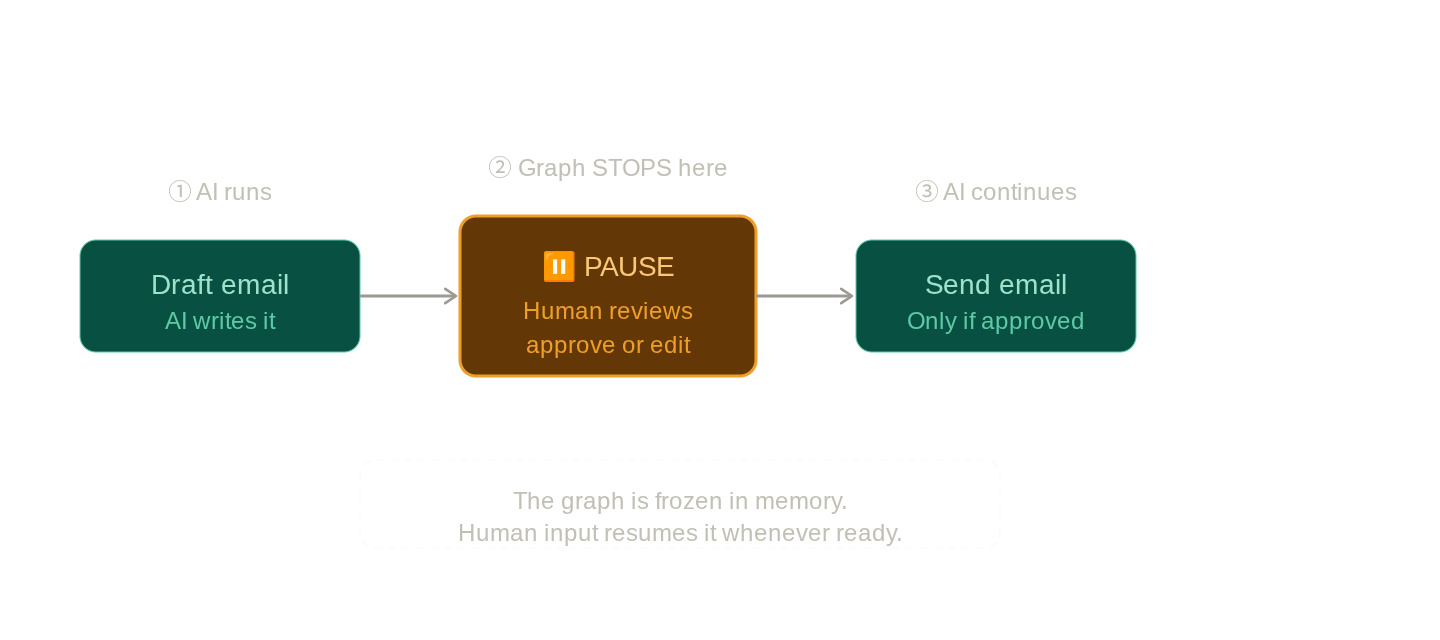




*   Step 1 — A normal graph (no human-in-the-loop yet)
*   Step 2 — Add a checkpointer (this is what makes pausing possible)
*   Step 3 — Tell it WHERE to pause with interrupt_before
*   Step 4 — Resume the graph (human gives the go-ahead)





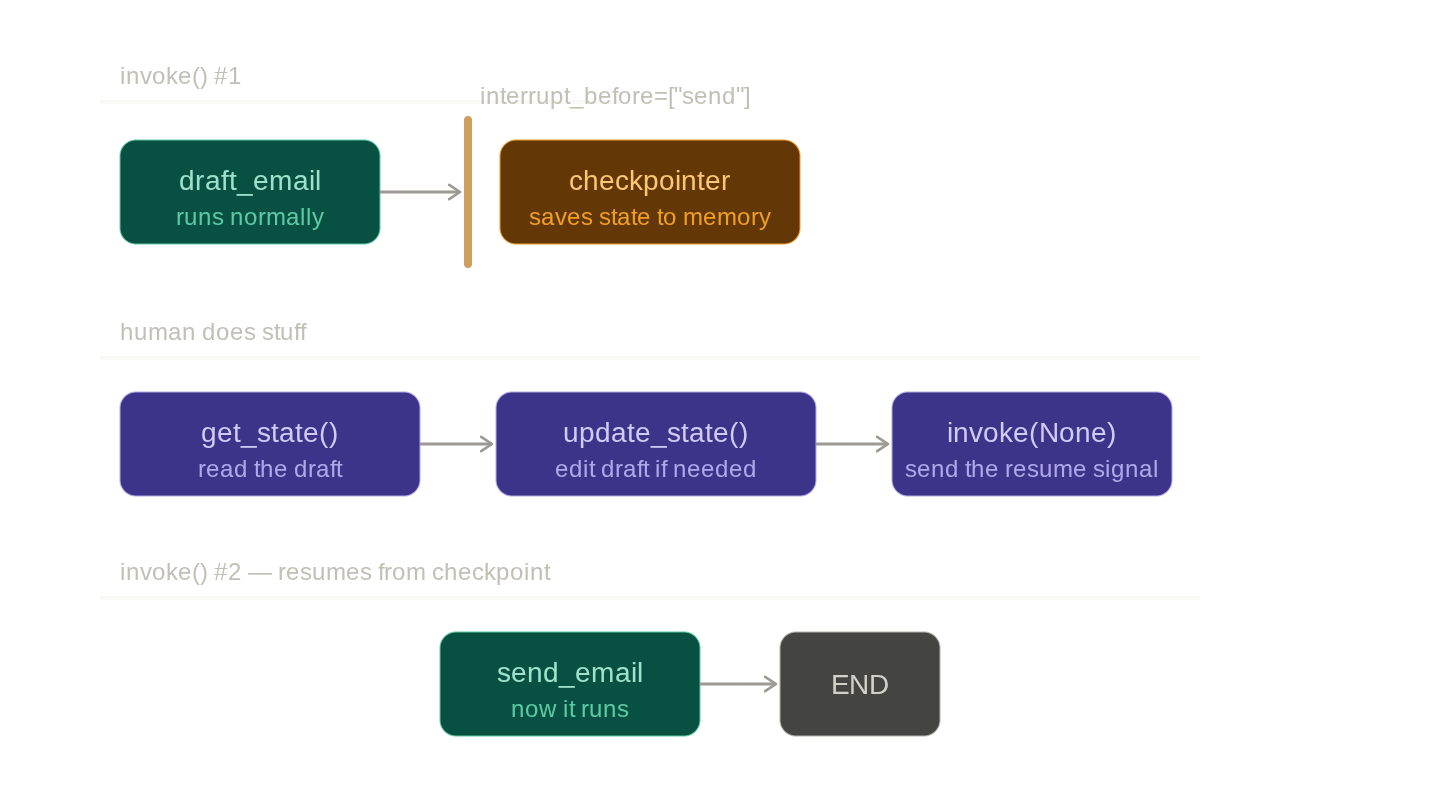

# LangGraph Checkpointing & Interruptions Cheat Sheet
| Component / Parameter | What it does | Where it appears in code |
| :--- | :--- | :--- |
| **`MemorySaver()`** | Create the save slot. | `memory = MemorySaver()` |
| **`checkpointer`** | Attaches the save-slot graph | `compile(checkpointer=memory)` |
| **`interrupt_before`** | Says where to pause | `compile(interrupt_before=["send"])` |
| **`thread_id`** | The name of your save-file | `config = {"configurable": {"thread_id": "abc"}}` |


And then:


* First invoke() → runs up to the pause, stops
* get_state() → read what's in there
* update_state() → change it if you want
* Second invoke(None) → same thread_id → continues from where it stopped




## Quick Integration Example

```python
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph

# 1. Initialize the memory checkpointer
memory = MemorySaver()

# 2. Define your graph structure
builder = StateGraph(dict)
# (... add nodes and edges here ...)

# 3. Compile the graph with checkpointer and interruption points
app = builder.compile(
    checkpointer=memory,
    interrupt_before=["send"]  # Pauses the graph right before running the 'send' node
)

# 4. Execute the graph using a specific thread_id
config = {"configurable": {"thread_id": "session_123"}}

# First run: will pause before the "send" node
events = app.stream({"input": "Hello"}, config)
for event in events:
    print(event)